**Task:** Binary classification — predict `Satisfaction`.

In [ ]:
# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and validation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# The three supplied supervised algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
RANDOM_STATE = 42

In [ ]:
df = pd.read_csv("airline_passenger_satisfaction.csv")
data_dictionary = pd.read_csv("data_dictionary.csv")

In [3]:
pd.DataFrame(data_dictionary)

,Field,Description
0,ID,Unique passenger identifier
1,Gender,Gender of the passenger (Female/Male)
2,Age,Age of the passenger
3,Customer Type,Type of airline customer (First-time/Returning)
4,Type of Travel,Purpose of the flight (Business/Personal)
5,Class,Travel class in the airplane for the passenger...
6,Flight Distance,Flight distance in miles
7,Departure Delay,Flight departure delay in minutes
8,Arrival Delay,Flight arrival delay in minutes
9,Departure and Arrival Time Convenience,Satisfaction level with the convenience of the...


In [36]:
df.shape

(129880, 22)

In [5]:
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


## 1. Exploratory Data Analysis

In [7]:
df.dtypes

ID                                          int64
Gender                                        str
Age                                         int64
Customer Type                                 str
Type of Travel                                str
Class                                         str
Flight Distance                             int64
Departure Delay                             int64
Arrival Delay                             float64
Departure and Arrival Time Convenience      int64
Ease of Online Booking                      int64
Check-in Service                            int64
Online Boarding                             int64
Gate Location                               int64
On-board Service                            int64
Seat Comfort                                int64
Leg Room Service                            int64
Cleanliness                                 int64
Food and Drink                              int64
In-flight Service                           int64


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum()

ID                                          0
Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Entertainment           

In [10]:
df.fillna(df.median(numeric_only=True), inplace=True)

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,129876,Male,28,Returning,Personal,Economy Plus,447,2,3.0,4,...,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129876,129877,Male,41,Returning,Personal,Economy Plus,308,0,0.0,5,...,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129877,129878,Male,42,Returning,Personal,Economy Plus,337,6,14.0,5,...,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied
129878,129879,Male,50,Returning,Personal,Economy Plus,337,31,22.0,4,...,4,4,5,3,3,4,5,3,5,Satisfied


In [11]:
df.isna().sum()

ID                                        0
Gender                                    0
Age                                       0
Customer Type                             0
Type of Travel                            0
Class                                     0
Flight Distance                           0
Departure Delay                           0
Arrival Delay                             0
Departure and Arrival Time Convenience    0
Ease of Online Booking                    0
Check-in Service                          0
Online Boarding                           0
Gate Location                             0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight Entertainment                   0
Baggage Handling                

In [12]:
df.drop(columns=["ID"], inplace=True)

In [13]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,129880,2,Female,65899,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,129880.0,NaN,NaN,NaN,39.427957,15.11936,7.0,27.0,40.0,51.0,85.0
Customer Type,129880,2,Returning,106100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type of Travel,129880,2,Business,89693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,129880,3,Business,62160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,129880.0,NaN,NaN,NaN,1190.316392,997.452477,31.0,414.0,844.0,1744.0,4983.0
Departure Delay,129880.0,NaN,NaN,NaN,14.713713,38.071126,0.0,0.0,0.0,12.0,1592.0
Arrival Delay,129880.0,NaN,NaN,NaN,15.045465,38.416353,0.0,0.0,0.0,13.0,1584.0
Departure and Arrival Time Convenience,129880.0,NaN,NaN,NaN,3.057599,1.526741,0.0,2.0,3.0,4.0,5.0
Ease of Online Booking,129880.0,NaN,NaN,NaN,2.756876,1.40174,0.0,2.0,3.0,4.0,5.0


C:\Users\AM BUSINESS 99\AppData\Local\Temp\ipykernel_13908\2677955424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Satisfaction", palette="viridis")


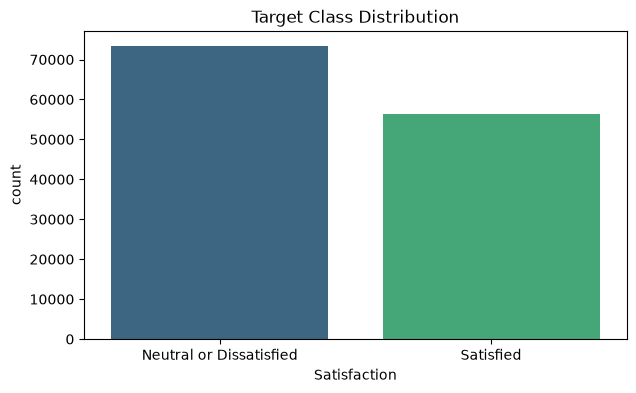

In [14]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Satisfaction", palette="viridis")
plt.title("Target Class Distribution")
plt.show()

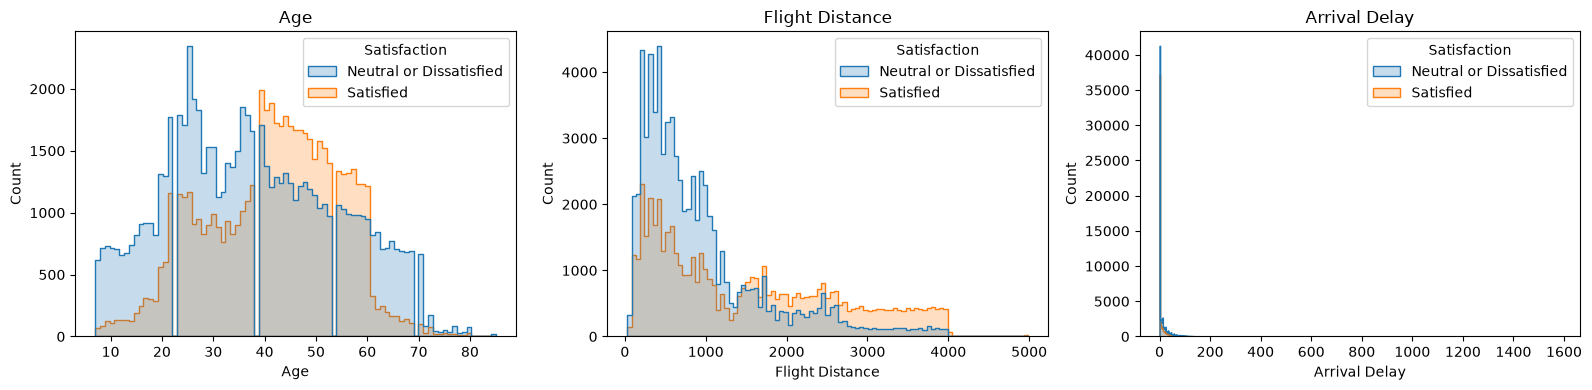

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, column in zip(axes, ["Age", "Flight Distance", "Arrival Delay"]):
    sns.histplot(data=df, x=column, hue="Satisfaction", element="step", ax=ax)
    ax.set_title(column)
plt.tight_layout(); plt.show()

C:\Users\AM BUSINESS 99\AppData\Local\Temp\ipykernel_13908\232765002.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Satisfaction", y=feature, data=df, ax=ax, palette=["#e74c3c", "#2ecc71"])
C:\Users\AM BUSINESS 99\AppData\Local\Temp\ipykernel_13908\232765002.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["NO", "Yes"])
C:\Users\AM BUSINESS 99\AppData\Local\Temp\ipykernel_13908\232765002.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Satisfaction", y=feature, data=df, ax=ax, palette=["#e74c3c", "#2ecc71"])
C:\Users\AM BUSINESS 99\App

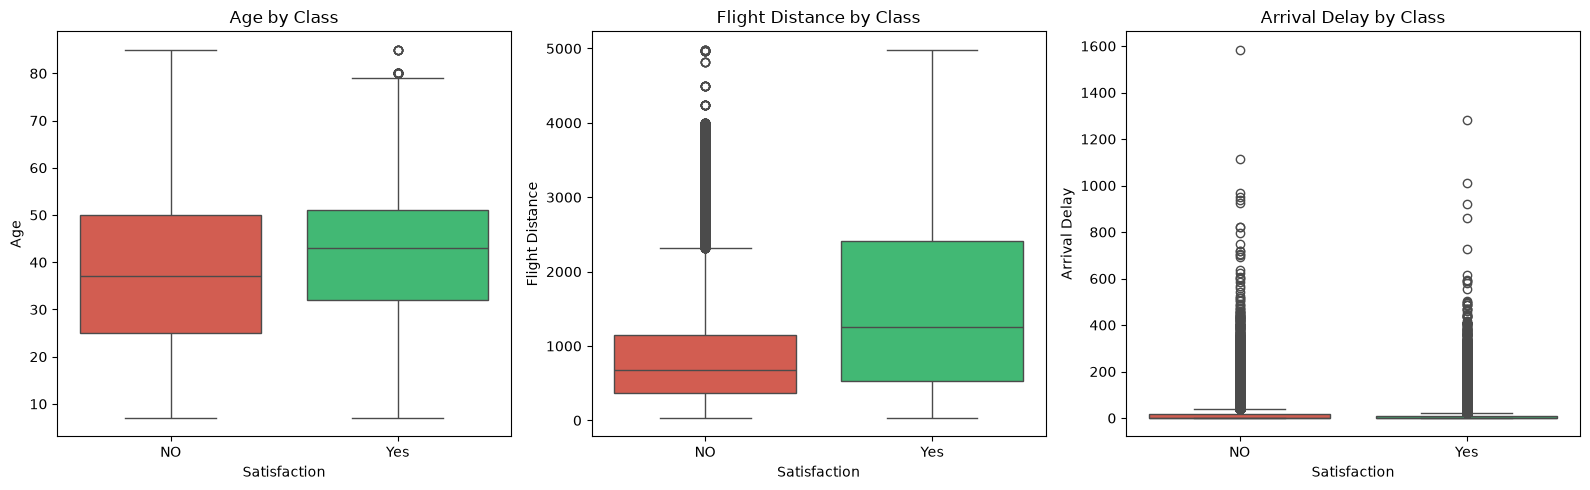

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feature in zip(axes, ["Age", "Flight Distance", "Arrival Delay"]):
    sns.boxplot(x="Satisfaction", y=feature, data=df, ax=ax, palette=["#e74c3c", "#2ecc71"])
    ax.set_xticklabels(["NO", "Yes"])
    ax.set_title(f"{feature} by Class")

plt.tight_layout()
plt.show()

In [17]:
df.drop(columns=["Arrival Delay"], inplace=True)

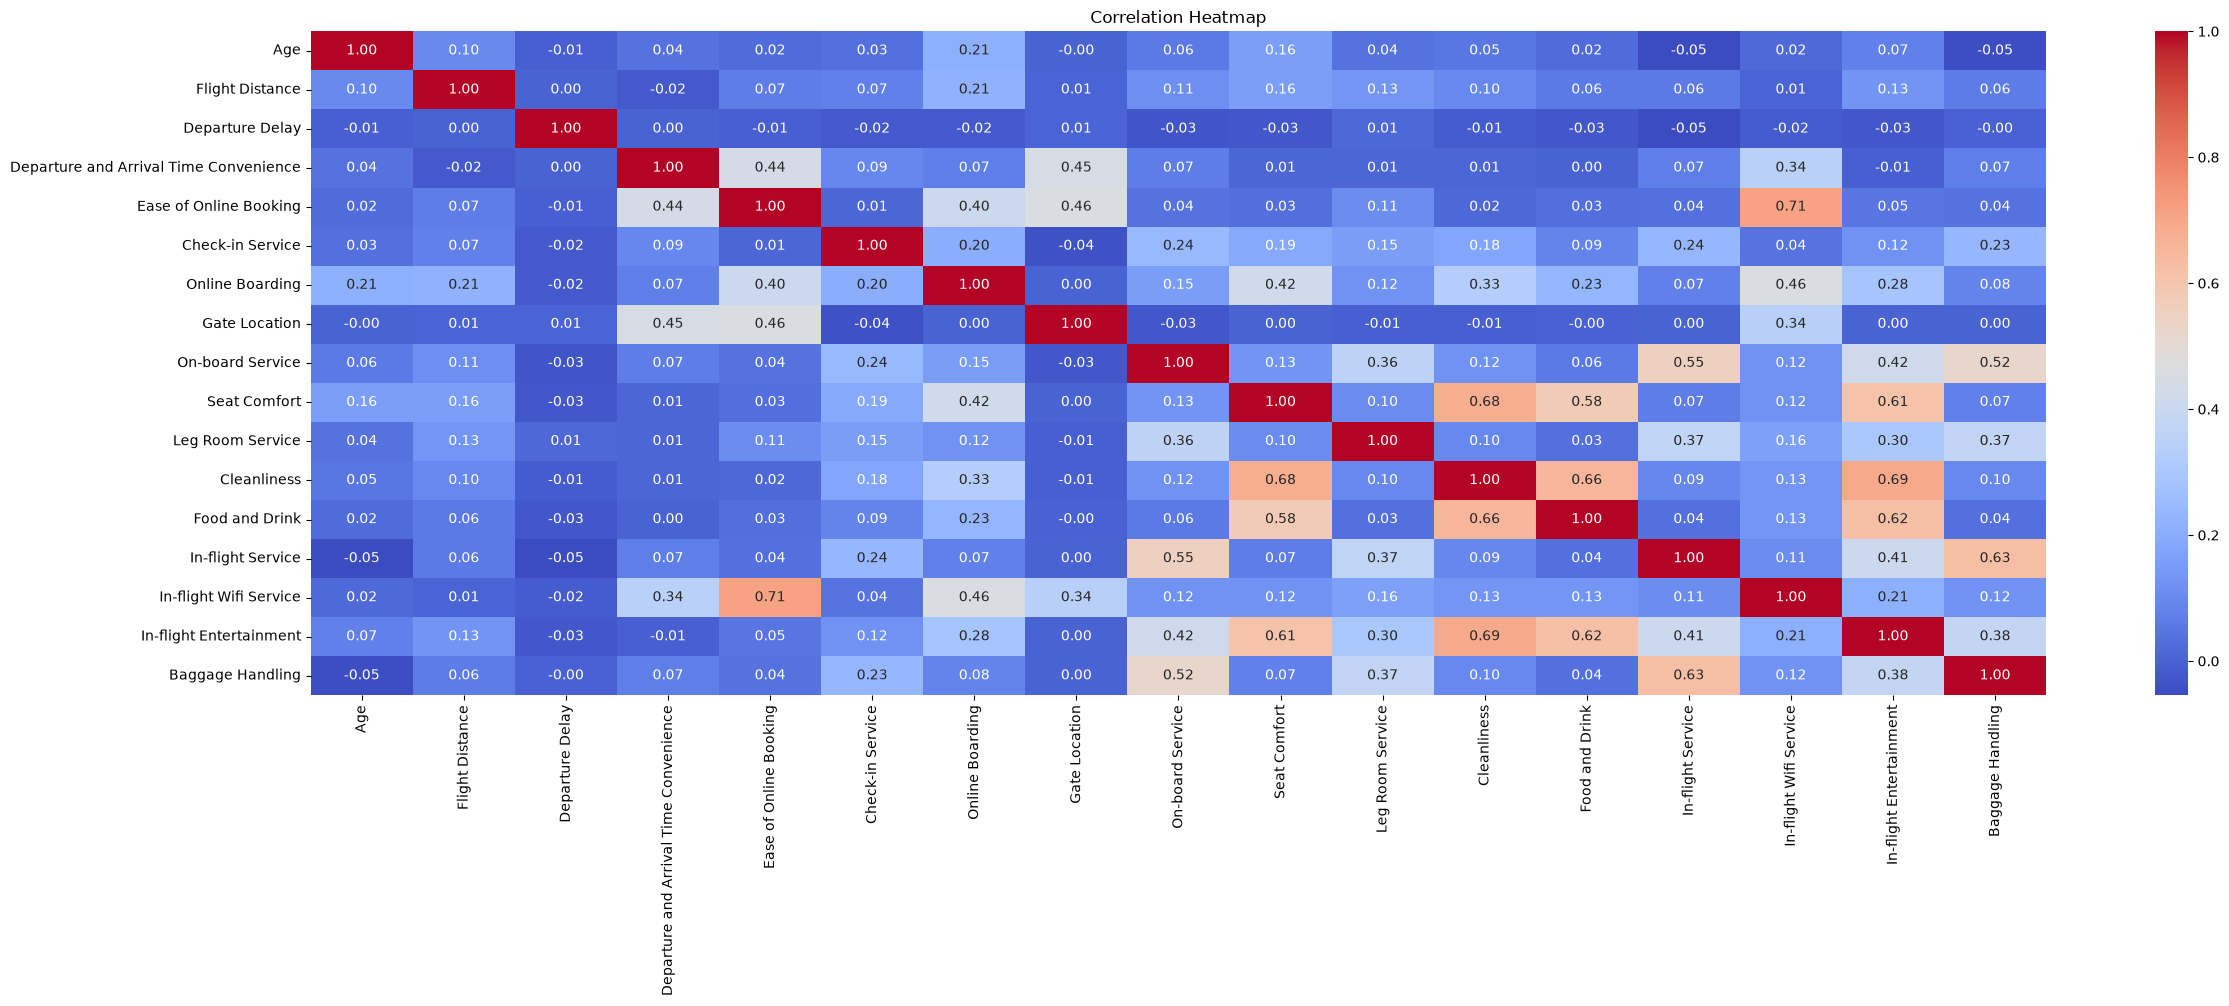

In [18]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

corr = df[numerical_features].corr(numeric_only=True)

plt.figure(figsize=(25, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm",fmt='.2f')
plt.tight_layout()
plt.title("Correlation Heatmap")
plt.show()

## 2. Train-Test Split Before Preprocessing

In [19]:
label_encoder = LabelEncoder()
X = df.drop(columns=["Satisfaction"])
y = label_encoder.fit_transform(df["Satisfaction"])

In [20]:
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return ((series < lower) | (series > upper)).sum()

outlier_summary = df[numerical_features].apply(count_outliers_iqr).sort_values(ascending=False)
print("Top 10 features by outlier count:")
outlier_summary.head(10)

Top 10 features by outlier count:


Departure Delay                           18098
Check-in Service                          16109
Flight Distance                            2855
Age                                           0
Departure and Arrival Time Convenience        0
Ease of Online Booking                        0
Online Boarding                               0
Gate Location                                 0
On-board Service                              0
Seat Comfort                                  0
dtype: int64

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train class proportions:", pd.Series(y_train).value_counts(normalize=True).sort_index().round(4).to_dict())

Train class proportions: {0: 0.5655, 1: 0.4345}


## 3. Missing Values, One-Hot Encoding and Standardization

In [ ]:
numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Numeric missing values: training medians only.
train_medians = X_train[numeric_columns].median()
X_train_num = X_train[numeric_columns].fillna(train_medians)
X_test_num = X_test[numeric_columns].fillna(train_medians)

# Nominal categories: training modes followed by supplied OneHotEncoder.

train_modes = X_train[categorical_columns].mode().iloc[0]
X_train_cat = X_train[categorical_columns].fillna(train_modes)
X_test_cat = X_test[categorical_columns].fillna(train_modes)
onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat_encoded = onehot_encoder.fit_transform(X_train_cat)
X_test_cat_encoded = onehot_encoder.transform(X_test_cat)

In [ ]:
# Supplied StandardScaler; fitted only on training numeric values.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

X_train_processed = np.hstack([X_train_scaled, X_train_cat_encoded])
X_test_processed = np.hstack([X_test_scaled, X_test_cat_encoded])

## Cross Validation, Regularization, Tuning and Three Models

In [24]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_model = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
baseline_scores = cross_val_score(
    baseline_model, X_train_scaled, y_train,
    cv=cv_strategy, scoring="f1"
)
print("Baseline Logistic Regression fold F1 scores:", np.round(baseline_scores, 4))
print("Mean CV F1:", round(baseline_scores.mean(), 4),
      "| Standard deviation:", round(baseline_scores.std(), 4))

Baseline Logistic Regression fold F1 scores: [0.7984 0.7946 0.7958 0.7962 0.7996]
Mean CV F1: 0.7969 | Standard deviation: 0.0018


In [25]:
regularization_results = []
for penalty in ["l1", "l2"]:
    model = LogisticRegression(
        penalty=penalty, solver="liblinear", C=1.0,
        max_iter=10000, random_state=RANDOM_STATE
    )
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=cv_strategy, scoring="f1")
    regularization_results.append({
        "Penalty": penalty.upper(),
        "Mean CV F1": scores.mean(),
        "CV F1 Std": scores.std()
    })
print(pd.DataFrame(regularization_results).round(4))

c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use

  Penalty  Mean CV F1  CV F1 Std
0      L1      0.7969     0.0018
1      L2      0.7969     0.0018


In [26]:
param_grid = {
    "C": [0.001, 0.01,0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

In [27]:
grid_search = GridSearchCV(
    LogisticRegression(max_iter=10000, random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="f1"
)
grid_search.fit(X_train_scaled, y_train)
print("Best Logistic Regression parameters:", grid_search.best_params_)
print("Best Logistic Regression CV F1:", round(grid_search.best_score_))

c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use

Best Logistic Regression parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Logistic Regression CV F1: 1


In [28]:
SVM_TRAIN_LIMIT = 25000
X_svm_train, _, y_svm_train, _ = train_test_split(
X_train_scaled, y_train, train_size=SVM_TRAIN_LIMIT,
random_state=RANDOM_STATE, stratify=y_train
)
print("SVM training rows:", len(X_svm_train))

SVM training rows: 25000


In [29]:
models = {
    "Logistic Regression": grid_search.best_estimator_,
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE
    ),
    "SVM (RBF Kernel)": SVC(
        kernel="rbf", probability=True, random_state=RANDOM_STATE
    )
}

In [30]:
trained_models = {}
train_f1 = {}
for name, model in models.items():
    model.fit(X_svm_train, y_svm_train)
    train_prediction = model.predict(X_svm_train)
    train_f1[name] = f1_score(y_svm_train, train_prediction)

    trained_models[name] = model
    print(name, "trained successfully.")

Logistic Regression trained successfully.


c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Random Forest trained successfully.


c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM (RBF Kernel) trained successfully.


## 5. Model Evaluation

In [31]:
eval_rows = []
predictions = {}
probabilities = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_proba
    test_f1 = f1_score(y_test, y_pred)
    eval_rows.append({
        "Model": name,
        "Train F1": train_f1[name],
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": test_f1,
        "Test ROC-AUC": roc_auc_score(y_test, y_proba),
    })

eval_df = pd.DataFrame(eval_rows).set_index("Model")
eval_df

,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
Model,,,,,,
Logistic Regression,0.799774,0.828342,0.814986,0.782562,0.798445,0.890138
Random Forest,1.000000,0.942716,0.946175,0.920521,0.933172,0.987254
SVM (RBF Kernel),0.928748,0.930628,0.929218,0.909623,0.919316,0.977529


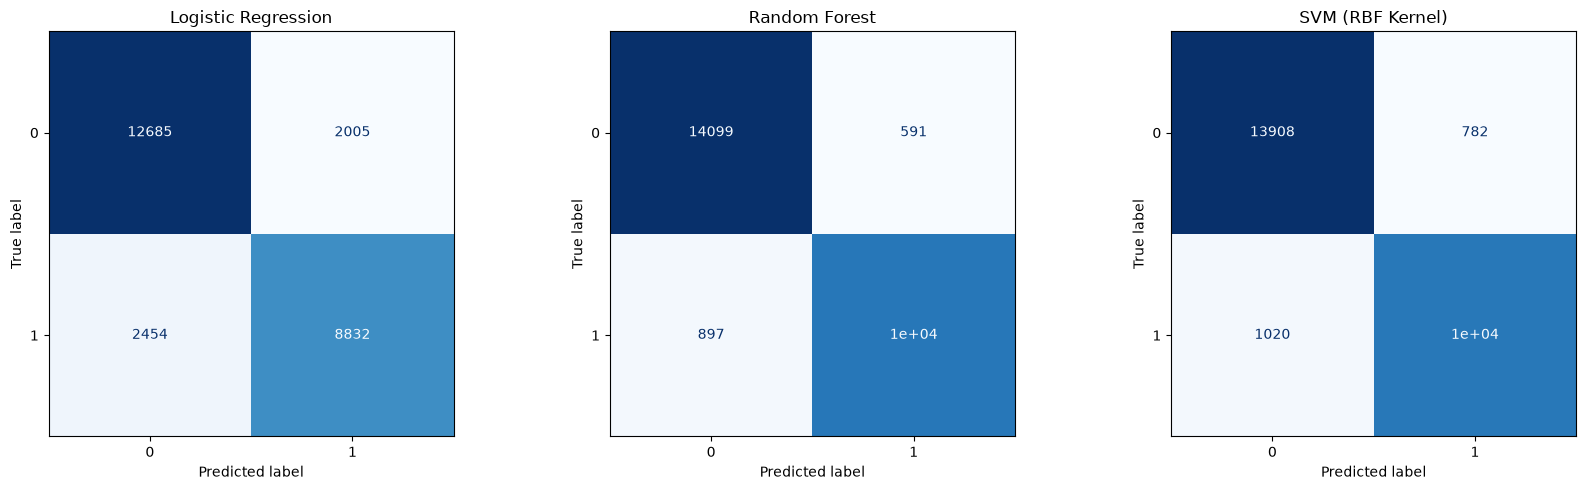

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (name, model) in zip(axes, trained_models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions[name], ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

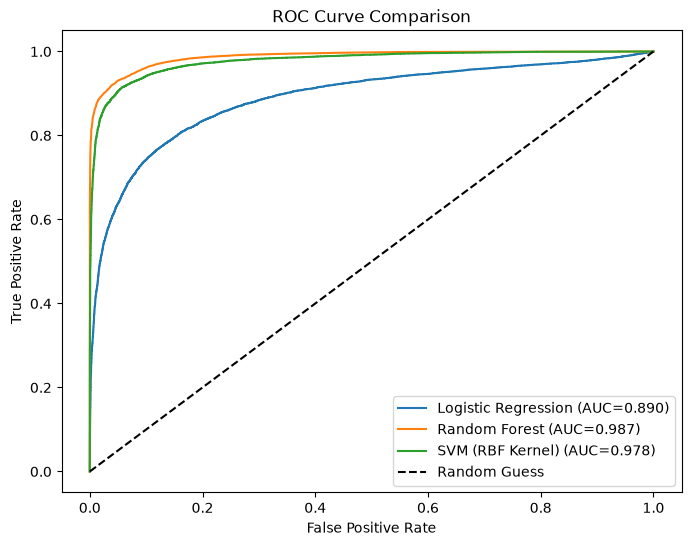

In [33]:
plt.figure(figsize=(8, 6))
for name in trained_models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_value = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [34]:
best_model_name = eval_df["Test F1"].idxmax()
print("Best model by Test F1:", best_model_name)
print("\nClassification Report:\n")
print(classification_report(y_test, predictions[best_model_name]))

Best model by Test F1: Random Forest

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95     14690
           1       0.95      0.92      0.93     11286

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976



## 6. Final Model and Overfit/Underfit Check

In [35]:
best_row = eval_df.loc[best_model_name]
print("Final selected model:", best_model_name)
print(best_row.round(4).to_string())

Final selected model: Random Forest
Train F1          1.0000
Test Accuracy     0.9427
Test Precision    0.9462
Test Recall       0.9205
Test F1           0.9332
Test ROC-AUC      0.9873
